# Feature And Target Distributions

This notebook is strictly for distribution diagnostics: missingness, tails, outliers, winsorized views, and feature/target shape checks. It does not build IC tables or research conclusions.

Default bucket size is 5 minutes.

In [1]:
from __future__ import annotations

import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

if "notebooks" not in sys.path:
    sys.path.append("notebooks")

from advanced_features import (
    build_feature_set,
    build_targets,
    discover_datasets,
    latest_feature_date,
)

ROOT = Path(os.environ.get("MODL_WS_NORMALIZED_DIR", "/mnt/burner-archive/ws_normalized")).expanduser()
DATE = os.environ.get("MODL_VIEW_DATE") or latest_feature_date(ROOT)
DATE_TAG = datetime.strptime(DATE, "%Y-%m-%d").strftime("%y-%m-%d")
BAR_MINUTES = int(os.environ.get("MODL_BAR_MINUTES", "5"))
HORIZONS = (5, 15, 30)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 240)
pd.set_option("display.max_colwidth", 180)
pl.Config.set_tbl_cols(240)
pl.Config.set_tbl_rows(24)

DATASETS = discover_datasets(ROOT, DATE_TAG)
if not DATASETS:
    raise FileNotFoundError(f"No normalized Parquet files found under {ROOT} for {DATE}")

ROOT, DATE, DATE_TAG, BAR_MINUTES, len(DATASETS)


(PosixPath('/mnt/burner-archive/ws_normalized'),
 '2026-07-01',
 '26-07-01',
 5,
 14)

## Build Feature Set And Targets

In [2]:
feature_set = build_feature_set(DATASETS, horizons=HORIZONS, bar_minutes=BAR_MINUTES)
feature_matrix = feature_set.feature_matrix
base_feature_matrix = feature_set.base_feature_matrix
trade_features = feature_set.trade_features
book_features = feature_set.book_features
deribit_option_features = feature_set.deribit_option_features
term_structure_features = feature_set.term_structure
option_smile_features = feature_set.option_smile
futures_basis_features = feature_set.futures_basis
funding_features = feature_set.funding_features
rv_features = feature_set.rv_features
reference_price = feature_set.reference_price

df = feature_matrix
df_stats = df.describe().T

component_shapes = pd.DataFrame(
    [
        ("feature_matrix", *feature_matrix.shape),
        ("base_feature_matrix", *base_feature_matrix.shape),
        ("trade_features", trade_features.height, trade_features.width),
        ("book_features", book_features.height, book_features.width),
        ("deribit_option_features", *deribit_option_features.shape),
        ("term_structure_features", *term_structure_features.shape),
        ("option_smile_features", *option_smile_features.shape),
        ("futures_basis_features", *futures_basis_features.shape),
        ("funding_features", *funding_features.shape),
        ("rv_features", *rv_features.shape),
    ],
    columns=["component", "rows", "columns"],
)
component_shapes

,component,rows,columns
0,feature_matrix,288,436
1,base_feature_matrix,288,28
2,trade_features,864,10
3,book_features,864,9
4,deribit_option_features,288,5
5,term_structure_features,288,15
6,option_smile_features,288,12
7,futures_basis_features,288,17
8,funding_features,288,2
9,rv_features,288,20


In [3]:
targets = build_targets(reference_price, term_structure_features, HORIZONS, bar_minutes=BAR_MINUTES)
model_table = pd.concat([feature_matrix, targets], axis=1).sort_index()
feature_columns = [column for column in feature_matrix.select_dtypes(include=[np.number]).columns]
target_columns = list(targets.columns)
print(feature_matrix.shape, targets.shape, model_table.shape)

(288, 436) (288, 14) (288, 450)


## Coverage And Missingness

In [4]:
coverage = pd.DataFrame({
    "non_null": model_table.notna().sum(),
    "null": model_table.isna().sum(),
    "coverage": model_table.notna().mean(),
    "dtype": model_table.dtypes.astype(str),
}).sort_values("coverage")
coverage.head(120)

,non_null,null,coverage,dtype
term_slope_30_90_minus_0_7_z_5m,0,288,0.000000,float64
term_slope_90_plus_minus_7_30_z_5m,0,288,0.000000,float64
term_curvature_z_5m,0,288,0.000000,float64
iv_7_30d_z_5m,0,288,0.000000,float64
iv_90d_plus_z_5m,0,288,0.000000,float64
...,...,...,...,...
bpv_5m_mean_15m,284,4,0.986111,float64
bpv_5m_mean_30m,284,4,0.986111,float64
jump_share_5m_z_30m,284,4,0.986111,float64
jump_share_5m_mean_15m,284,4,0.986111,float64


## Distribution Summary

In [5]:
def distribution_summary(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for column in columns:
        s = frame[column].replace([np.inf, -np.inf], np.nan).dropna()
        if s.empty:
            continue
        q01, q05, q50, q95, q99 = s.quantile([0.01, 0.05, 0.50, 0.95, 0.99])
        rows.append({
            "column": column,
            "n": len(s),
            "mean": s.mean(),
            "std": s.std(),
            "skew": s.skew(),
            "kurtosis": s.kurtosis(),
            "q01": q01,
            "q05": q05,
            "median": q50,
            "q95": q95,
            "q99": q99,
            "min": s.min(),
            "max": s.max(),
            "iqr": s.quantile(0.75) - s.quantile(0.25),
        })
    return pd.DataFrame(rows)

dist_summary = distribution_summary(model_table, feature_columns + target_columns)
dist_summary.sort_values("kurtosis", ascending=False).head(80)

,column,n,mean,std,skew,kurtosis,q01,q05,median,q95,q99,min,max,iqr
27,funding_updates,288,988.888889,13.619831,-14.406815,226.347911,955.870000,990.000000,990.000000,991.000000,991.000000,772.000000,991.000000,1.000000
48,jump_var_15m,284,0.014895,0.089960,11.080546,140.877574,0.000000,0.000000,0.000000,0.051691,0.243868,0.000000,1.264064,0.000000
298,jump_var_15m_mean_5m,284,0.014895,0.089960,11.080546,140.877574,0.000000,0.000000,0.000000,0.051691,0.243868,0.000000,1.264064,0.000000
130,trade_trade_count_hyperliquid_mean_5m,288,72.656250,84.215316,9.306950,119.009554,19.000000,24.350000,56.000000,150.650000,327.000000,17.000000,1215.000000,40.250000
5,trade_trade_count_hyperliquid,288,72.656250,84.215316,9.306950,119.009554,19.000000,24.350000,56.000000,150.650000,327.000000,17.000000,1215.000000,40.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,bpv_5m_over_rv_5m_diff_5m,285,0.001659,2.159329,-0.209571,7.429829,-6.288960,-3.317548,0.027908,2.764334,6.077850,-10.622665,10.101892,1.781369
267,bpv_5m_diff_5m,285,-0.000261,0.267296,0.059144,7.396766,-0.789182,-0.387454,-0.000160,0.395397,0.720389,-1.479317,1.237968,0.212858
229,spread_bps_hibachi_minus_hyperliquid_mean_30m,286,-0.179965,0.047538,1.687986,6.998122,-0.274756,-0.247139,-0.181160,-0.100457,0.030491,-0.307548,0.063052,0.043436
193,book_spread_bps_hibachi_mean_30m,286,0.150100,0.130202,2.636593,6.901350,0.053564,0.065874,0.102058,0.466079,0.676434,0.039048,0.759750,0.071575


## Target Distributions

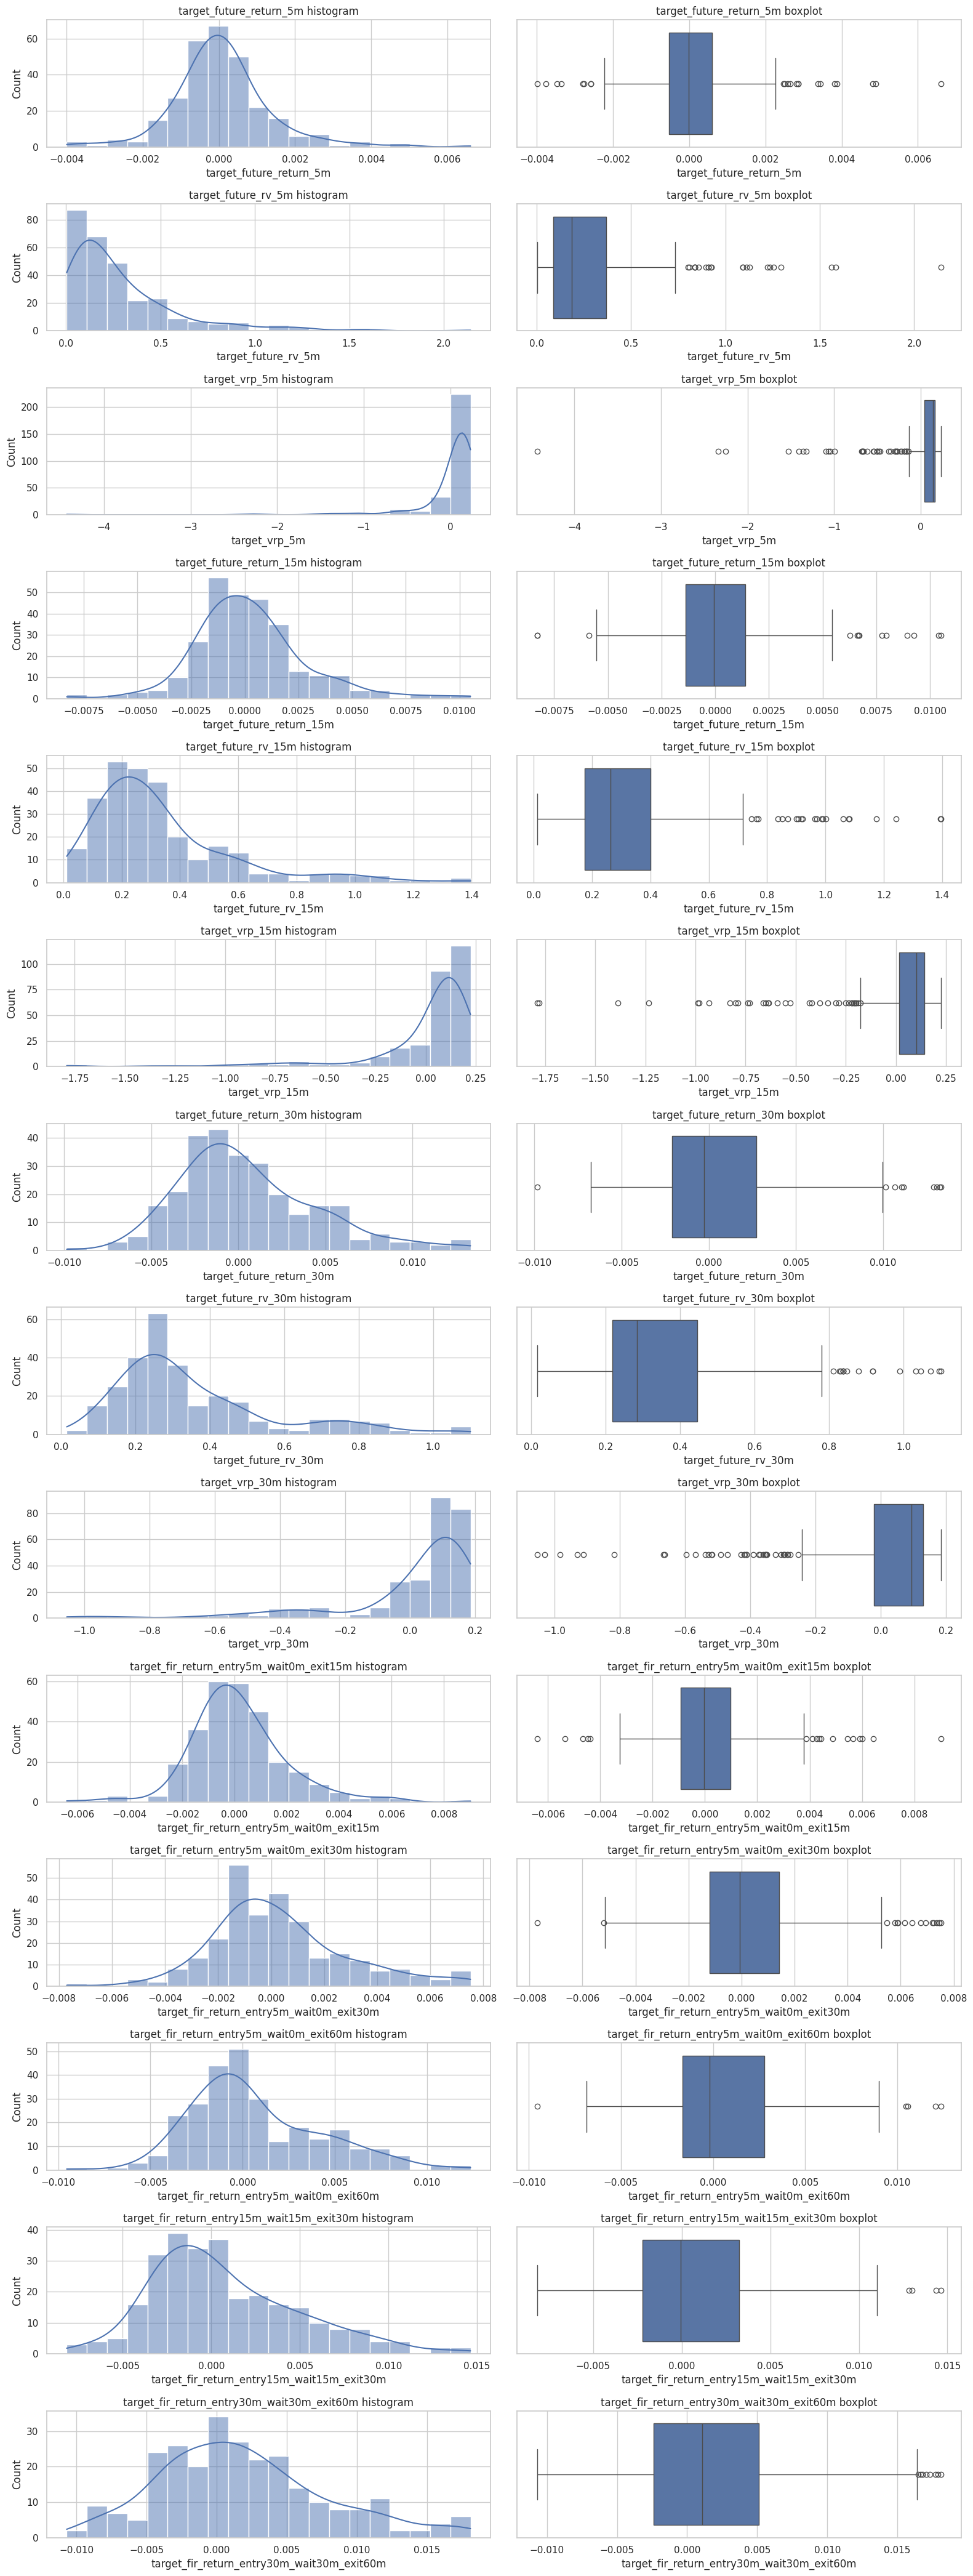

In [6]:
fig, axes = plt.subplots(len(target_columns), 2, figsize=(16, max(4, 3 * len(target_columns))))
for i, column in enumerate(target_columns):
    s = targets[column].replace([np.inf, -np.inf], np.nan).dropna()
    sns.histplot(s, bins=20, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{column} histogram")
    sns.boxplot(x=s, ax=axes[i, 1])
    axes[i, 1].set_title(f"{column} boxplot")
plt.tight_layout()

## Feature Family Histograms

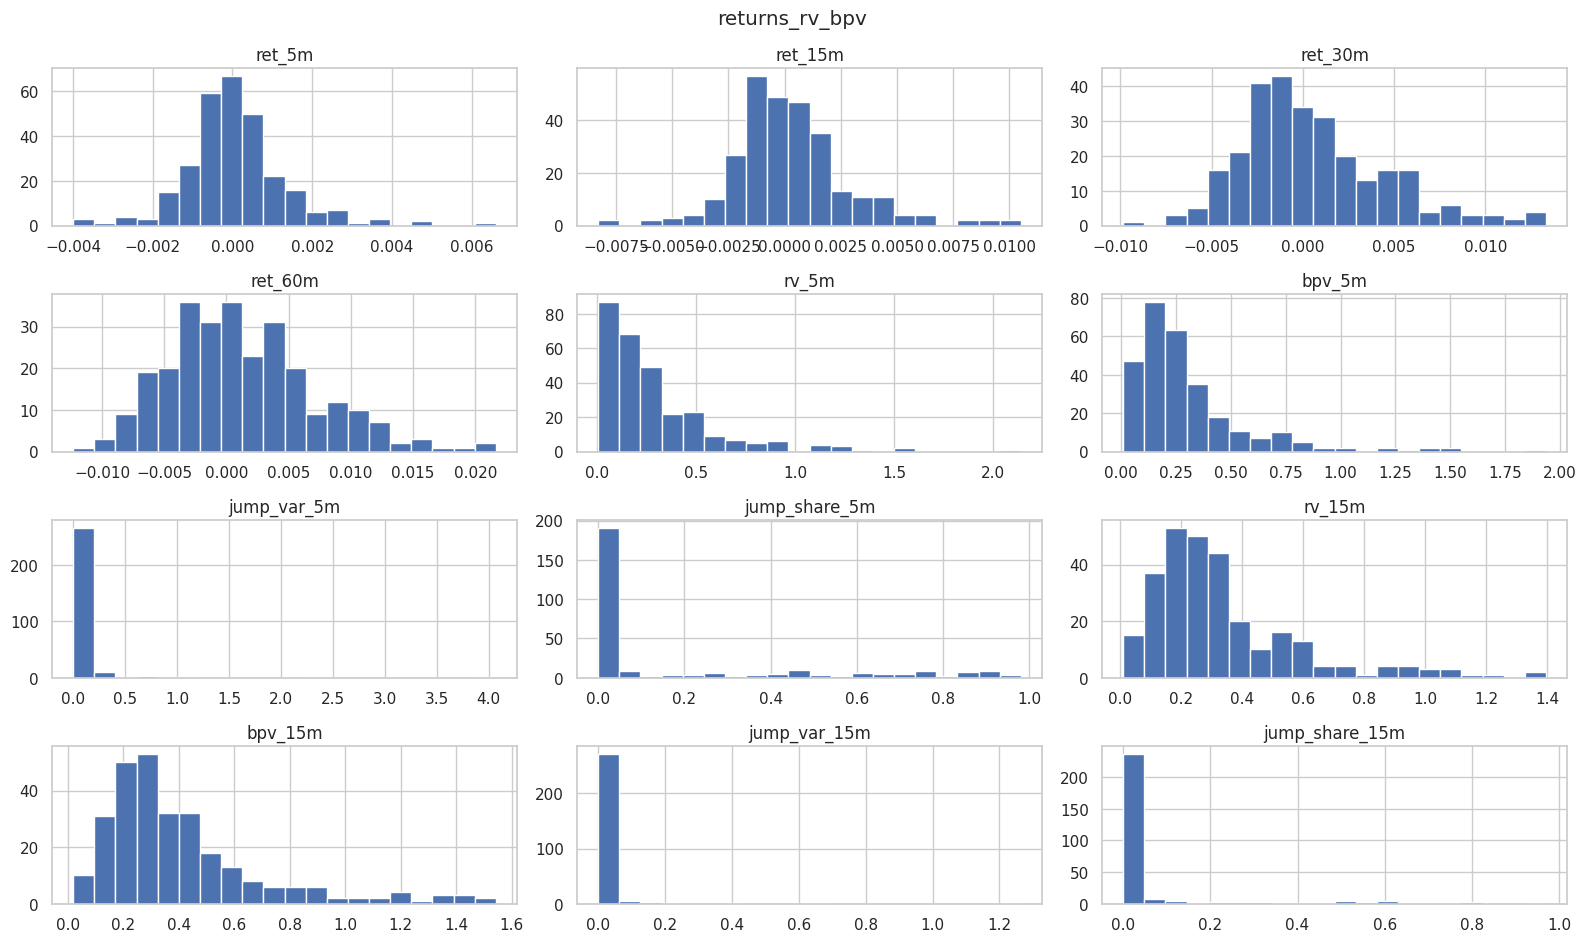

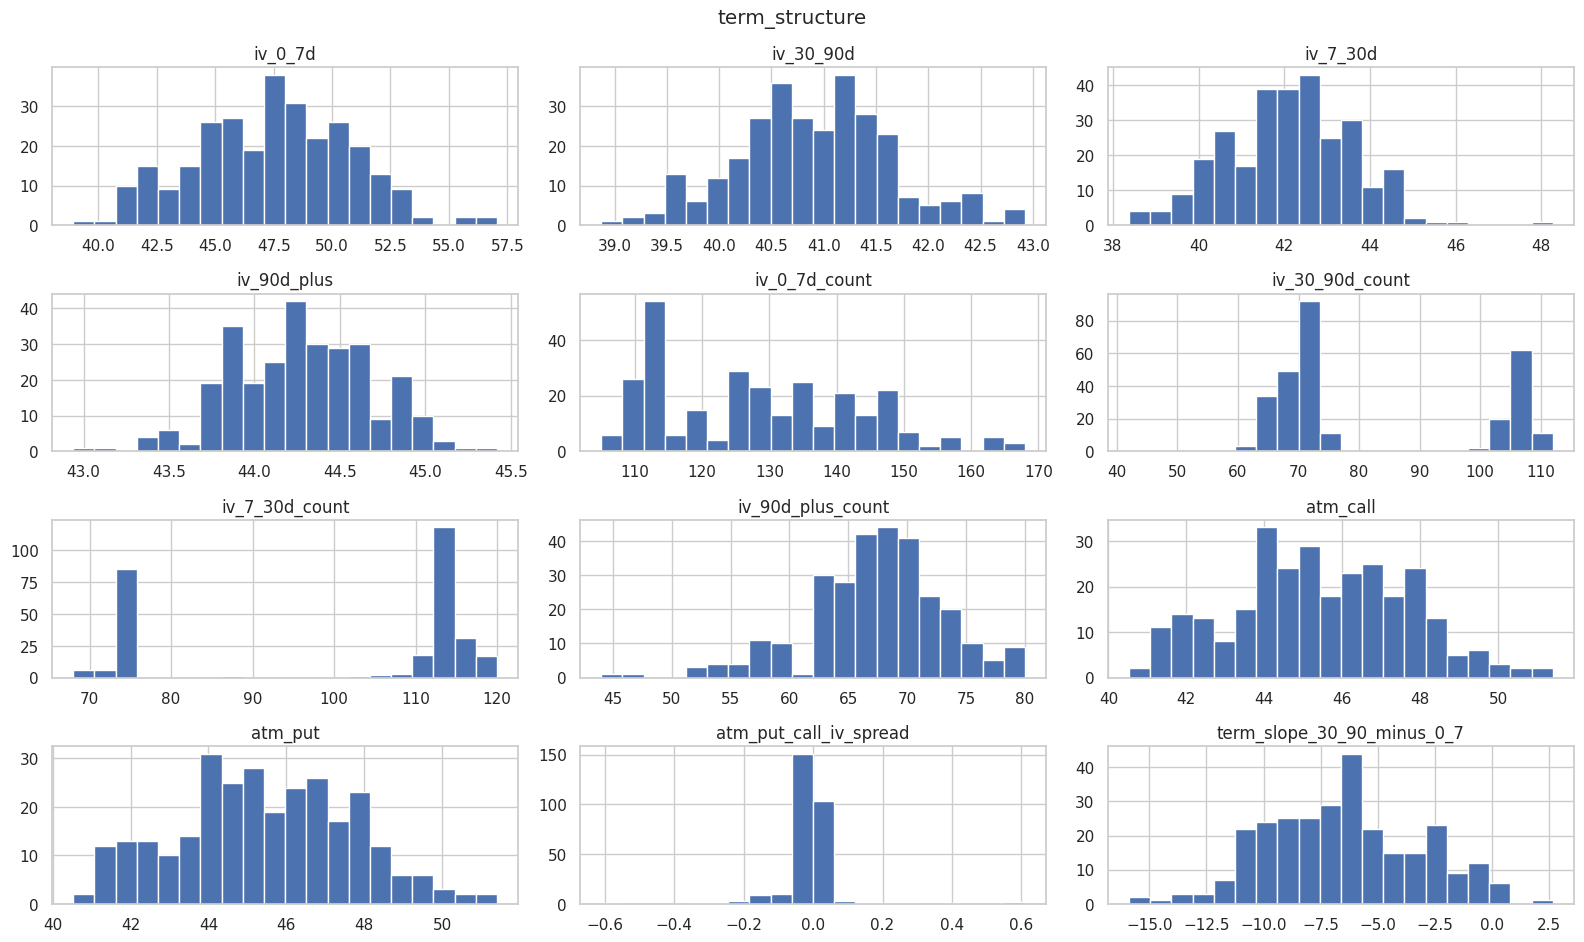

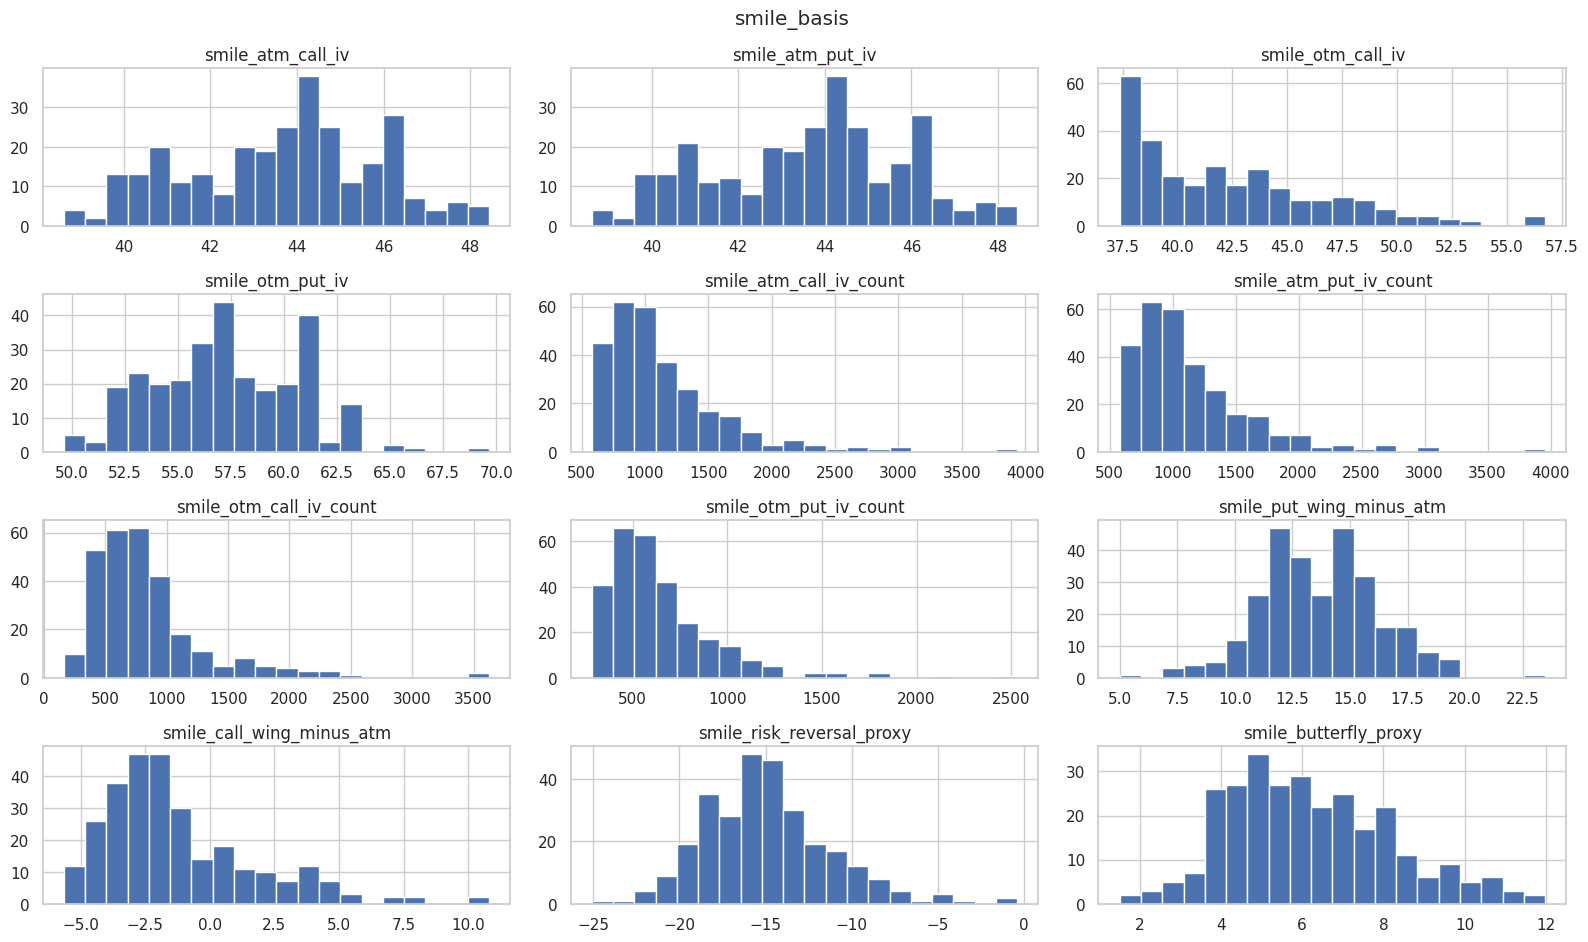

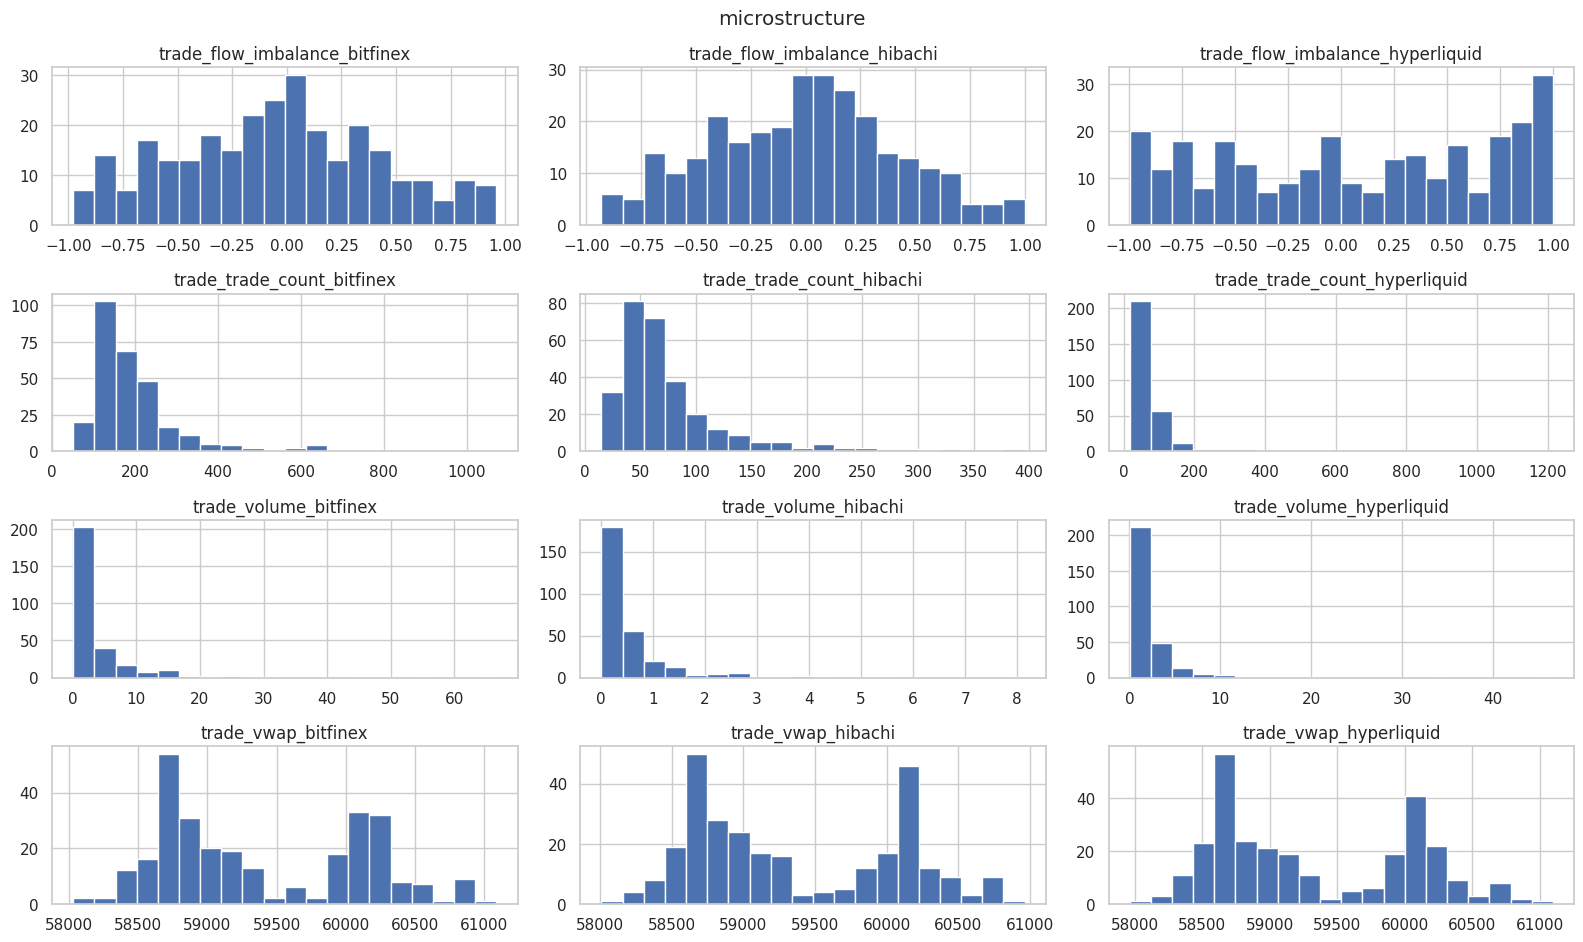

In [7]:
families = {
    "returns_rv_bpv": [c for c in feature_columns if c.startswith(("ret_", "rv_", "bpv_", "jump_"))][:12],
    "term_structure": [c for c in feature_columns if c.startswith(("iv_", "term_", "atm_", "short_iv"))][:12],
    "smile_basis": [c for c in feature_columns if c.startswith(("smile_", "basis_"))][:12],
    "microstructure": [c for c in feature_columns if c.startswith(("trade_", "book_", "cross_", "mid_", "spread_"))][:12],
}
for family, columns in families.items():
    if not columns:
        continue
    sample = model_table[columns].replace([np.inf, -np.inf], np.nan)
    axes = sample.hist(bins=20, figsize=(16, max(6, 2.4 * ((len(columns) + 2) // 3))), layout=((len(columns) + 2) // 3, 3))
    plt.suptitle(family)
    plt.tight_layout()

## Winsorized Distribution View

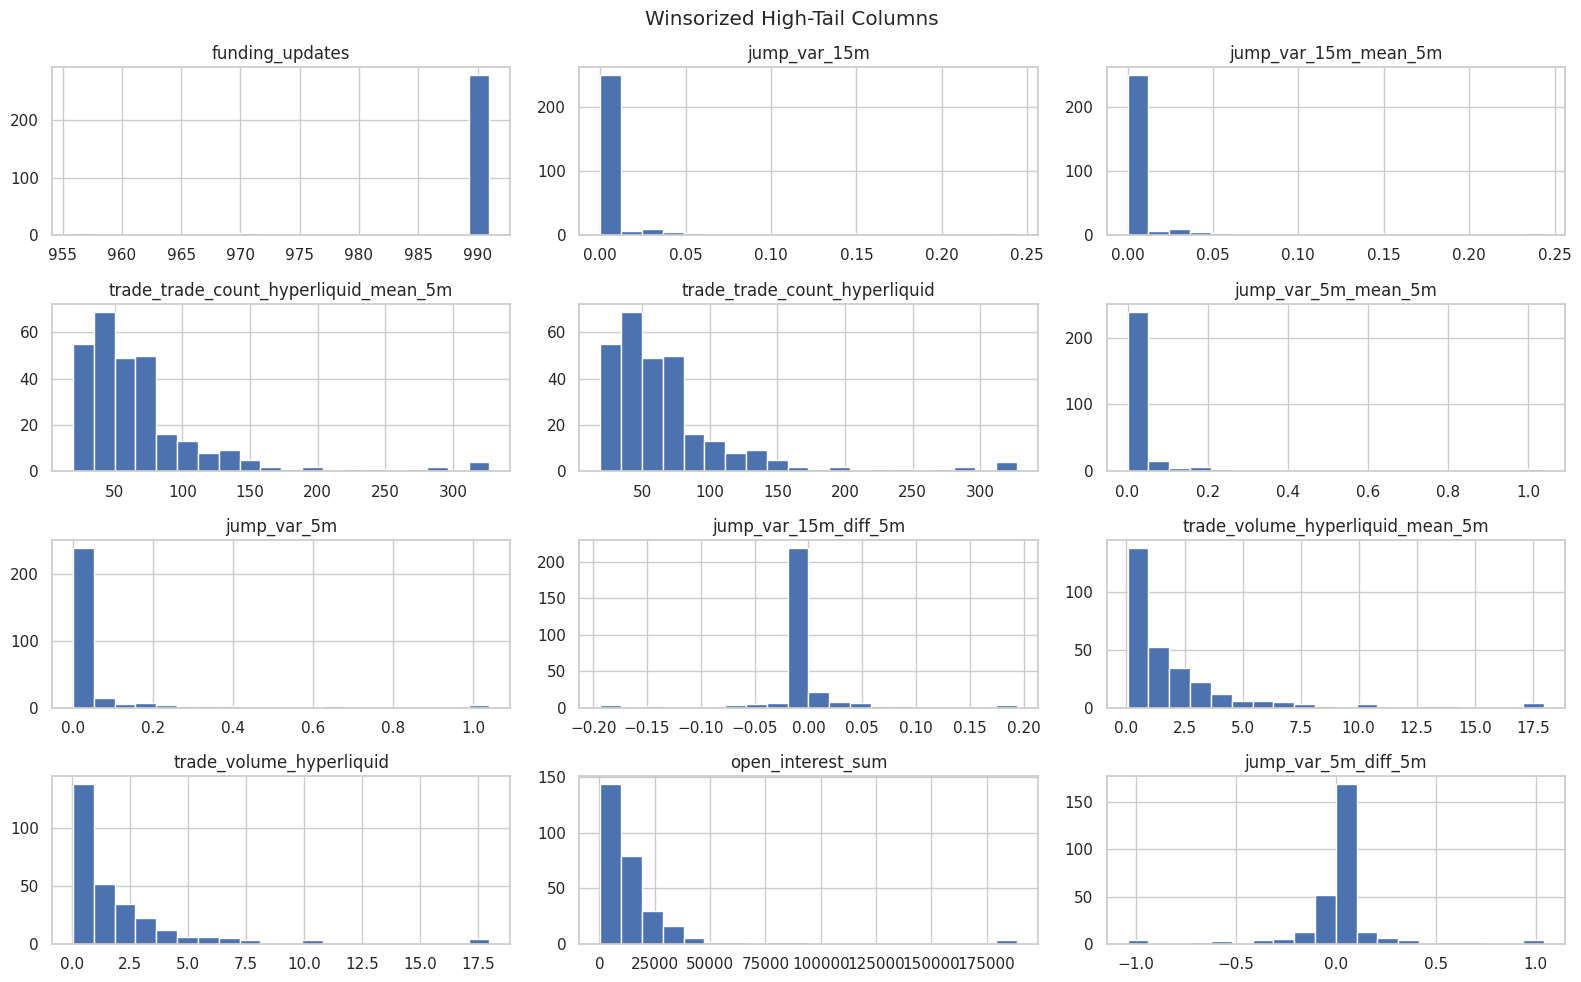

In [8]:
def winsorize_frame(frame: pd.DataFrame, columns: list[str], lower: float = 0.01, upper: float = 0.99) -> pd.DataFrame:
    out = frame[columns].copy()
    for column in columns:
        s = out[column].replace([np.inf, -np.inf], np.nan)
        lo, hi = s.quantile([lower, upper])
        out[column] = s.clip(lo, hi)
    return out

high_tail_cols = dist_summary.sort_values("kurtosis", ascending=False).head(12)["column"].tolist()
winsorized = winsorize_frame(model_table, high_tail_cols)
axes = winsorized.hist(bins=20, figsize=(16, 10), layout=(4, 3))
plt.suptitle("Winsorized High-Tail Columns")
plt.tight_layout()

## Outlier Table

In [9]:
outlier_rows = []
for column in feature_columns + target_columns:
    s = model_table[column].replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) < 5:
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0 or pd.isna(iqr):
        continue
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    count = ((s < lower) | (s > upper)).sum()
    outlier_rows.append({"column": column, "outliers_3iqr": count, "rate": count / len(s), "lower": lower, "upper": upper})
outliers = pd.DataFrame(outlier_rows).sort_values("rate", ascending=False)
outliers.head(80)

,column,outliers_3iqr,rate,lower,upper
298,jump_share_15m_z_30m,85,0.467033,-0.408248,-0.408248
294,jump_var_15m_z_30m,84,0.461538,-0.408248,-0.408248
267,jump_var_5m_diff_5m,90,0.315789,-0.049627,0.051109
44,jump_var_5m,47,0.164336,-0.036513,0.048683
268,jump_var_5m_mean_5m,47,0.164336,-0.036513,0.048683
...,...,...,...,...,...
125,trade_trade_count_hyperliquid_mean_15m,6,0.020979,-81.083333,207.083333
119,trade_trade_count_hibachi_mean_15m,6,0.020979,-68.500000,205.666667
30,spread_bps_hibachi_minus_hyperliquid,6,0.020833,-0.435647,0.071286
220,spread_bps_hibachi_minus_hyperliquid_mean_5m,6,0.020833,-0.435647,0.071286
